In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

from spd.sdfb_simulator import SDFB_Simulator

In [2]:
def rayleigh_taylor(xy: np.ndarray, case: int, P0=2.5, gamma=1):
    x = xy[0]
    y = xy[1]

    yc = 0.5
    rho1 = 2.0
    rho2 = 1.0

    if case == 0:
        # density
        return np.where(y > yc, rho2, rho1)
    elif case == 1:
        # vx
        return np.zeros(x.shape)
    elif case == 2:
        # vy
        dv = np.sqrt(gamma * (P0 + rho1 * yc - P0 + 1) / rho1)
        return -0.025 * dv * np.cos(8 * np.pi * x)
    elif case == 4:
        # Pressure
        return np.where(y > yc, P0 + rho2 * y + (rho1 - rho2) * yc, P0 + rho1 * y)
    elif case == -1:
        return 1.0 * y  # Phi; gives acceleration -g in y/x
    else:
        return np.zeros(x.shape)

In [3]:
Ny = 192
T = 1.95

In [4]:
spd_sim = SDFB_Simulator(
    N=(Ny // 4, Ny),
    xlim=(0.0, 0.25),
    ylim=(0.0, 1.0),
    BC=(
        ("periodic", "periodic"),  # x
        ("reflective", "reflective"),  # y
    ),
    init_fct=partial(rayleigh_taylor, P0=1.0, gamma=5 / 3),
    gamma=5 / 3,
    potential=True,
    scheme="FV",
    p=1,
    time_integrator="rk1",
    riemann_solver_sd="hllc",  # SD high-order flux
    riemann_solver_fv="hllc",  # MUSCL fallback flux
    use_cupy=False,
)

# Shape is (ndim, Ny, Nx) in 2D, (ndim, Nz, Ny, Nx) in 3D.
spd_sim.dm.grad_phi = np.zeros((spd_sim.ndim,) + spd_sim.dm.U_cv.shape[1:])
spd_sim.dm.grad_phi[spd_sim.dims["y"]] = -1.0

# ho = spd_sim.ho_scheme
# spd_sim.lo_scheme.dm.grad_phi = ho.transpose_to_fv(ho.compute_cv_from_sp(ho.dm.grad_phi_sp))
# spd_sim.lo_scheme.slope_limiter = spd_muscl_limiter("moncen")

spd_sim.perform_time_evolution(T)

/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: divide by zero encountered in divide
  ratio = SlopeR/SlopeL
/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = SlopeR/SlopeL


t=1.95, steps taken 3855, time taken 7.307, bzcps = 0.005


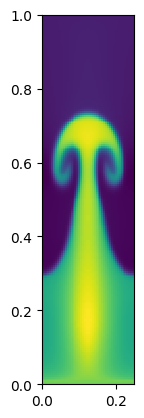

In [5]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
ax.set_aspect("equal")

x_sd = spd_sim.regular_faces()[0]
y_sd = spd_sim.regular_faces()[1]
z_sd = spd_sim.transpose_to_fv(spd_sim.regular_mesh(spd_sim.dm.W_cv))[0]

ax.pcolormesh(x_sd, y_sd, z_sd)